In [5]:
# Step 1: Read the local input file and configure shared tree settings.
from __future__ import annotations

import csv
from collections import Counter, defaultdict, deque
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
matplotlib.rcParams["font.size"] = 10.5

ROOT = Path.cwd()
if not (ROOT / "ctann-v9.csv").exists():
    ROOT = ROOT / "notebook"

INPUT = ROOT / "ctann-v9.csv"
OUTPUT_DIR = ROOT.parent / "vis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INCLUDED_SOURCES = {"azimuth", "pan-human-azimuth"}
SOURCE_DISPLAY_NAMES = {
    "azimuth": "Azimuth",
    "pan-human-azimuth": "Pan-Human Azimuth",
}
AZIMUTH_NODE_FILL_COLOR = "#E31A1C"
PAN_HUMAN_AZIMUTH_NODE_FILL_COLOR = "#1E90FF"
OVERLAP_NODE_FILL_COLOR = "#7B2CBF"
LABEL_FONT_SIZE = 10.5
COLUMNAR_CUBOIDAL_ROOT_ID = "CL:0000075"

rows = list(csv.DictReader(INPUT.open(newline="", encoding="utf-8-sig")))
for row in rows[:5]:
    print(row)


def get_tree_source_data(rows, *, max_as_level=None, root_id=None, expand_node_id=None):
    """Filter two sources and return path suffixes for one tree."""
    tree_rows = []
    source_counts = Counter()
    for row in rows:
        source_norm = row.get("CT/1 - Sources", "").strip().lower()
        if source_norm not in INCLUDED_SOURCES:
            continue

        full_path = []
        for level in range(1, 13):
            node_id = row.get(f"AS/{level}/ID", "").strip()
            node_label = row.get(f"AS/{level}/LABEL", "").strip()
            if node_id:
                full_path.append((node_id, node_label))

        if max_as_level:
            top_levels = full_path[:max_as_level]
            is_expanded_branch = expand_node_id and any(
                node_id == expand_node_id for node_id, _ in top_levels
            )
            path = full_path if is_expanded_branch else top_levels
        else:
            path = full_path

        if root_id:
            root_index = next(
                (index for index, (node_id, _) in enumerate(path) if node_id == root_id),
                None,
            )
            if root_index is None:
                continue
            path = path[root_index:]

        if not path:
            continue

        tree_rows.append((source_norm, path))
        source_counts[SOURCE_DISPLAY_NAMES[source_norm]] += 1

    return tree_rows, source_counts


{'1': '2', 'AS/1': 'cell', 'AS/1/ID': 'CL:0000000', 'AS/1/LABEL': 'cell', 'AS/2': 'endothelial cell', 'AS/2/ID': 'CL:0000115', 'AS/2/LABEL': 'endothelial cell', 'AS/3': 'endothelial cell of vascular tree', 'AS/3/ID': 'CL:0002139', 'AS/3/LABEL': 'endothelial cell of vascular tree', 'AS/4': 'blood vessel endothelial cell', 'AS/4/ID': 'CL:0000071', 'AS/4/LABEL': 'blood vessel endothelial cell', 'AS/5': '', 'AS/5/ID': '', 'AS/5/LABEL': '', 'AS/6': '', 'AS/6/ID': '', 'AS/6/LABEL': '', 'AS/7': '', 'AS/7/ID': '', 'AS/7/LABEL': '', 'AS/8': '', 'AS/8/ID': '', 'AS/8/LABEL': '', 'AS/9': '', 'AS/9/ID': '', 'AS/9/LABEL': '', 'AS/10': '', 'AS/10/ID': '', 'AS/10/LABEL': '', 'AS/11': '', 'AS/11/ID': '', 'AS/11/LABEL': '', 'AS/12': '', 'AS/12/ID': '', 'AS/12/LABEL': '', 'CT/1 - Sources': 'azimuth', 'BGene/1': 'sc_transcriptomics', 'NV notes': ''}
{'1': '3', 'AS/1': 'cell', 'AS/1/ID': 'CL:0000000', 'AS/1/LABEL': 'cell', 'AS/2': 'hematopoietic cell', 'AS/2/ID': 'CL:0000988', 'AS/2/LABEL': 'hematopoietic 

In [6]:
# Step 2: Get the source data for tree 1 (top three levels, with only the progenitor cell branch expanded to its leaves).
PROGENITOR_CELL_ID = "CL:0011026"
tree1_rows, tree1_source_counts = get_tree_source_data(
    rows,
    max_as_level=3,
    expand_node_id=PROGENITOR_CELL_ID,
)
print(f"Tree 1 paths: {len(tree1_rows)}")
print(dict(tree1_source_counts))


Tree 1 paths: 454
{'Azimuth': 247, 'Pan-Human Azimuth': 207}


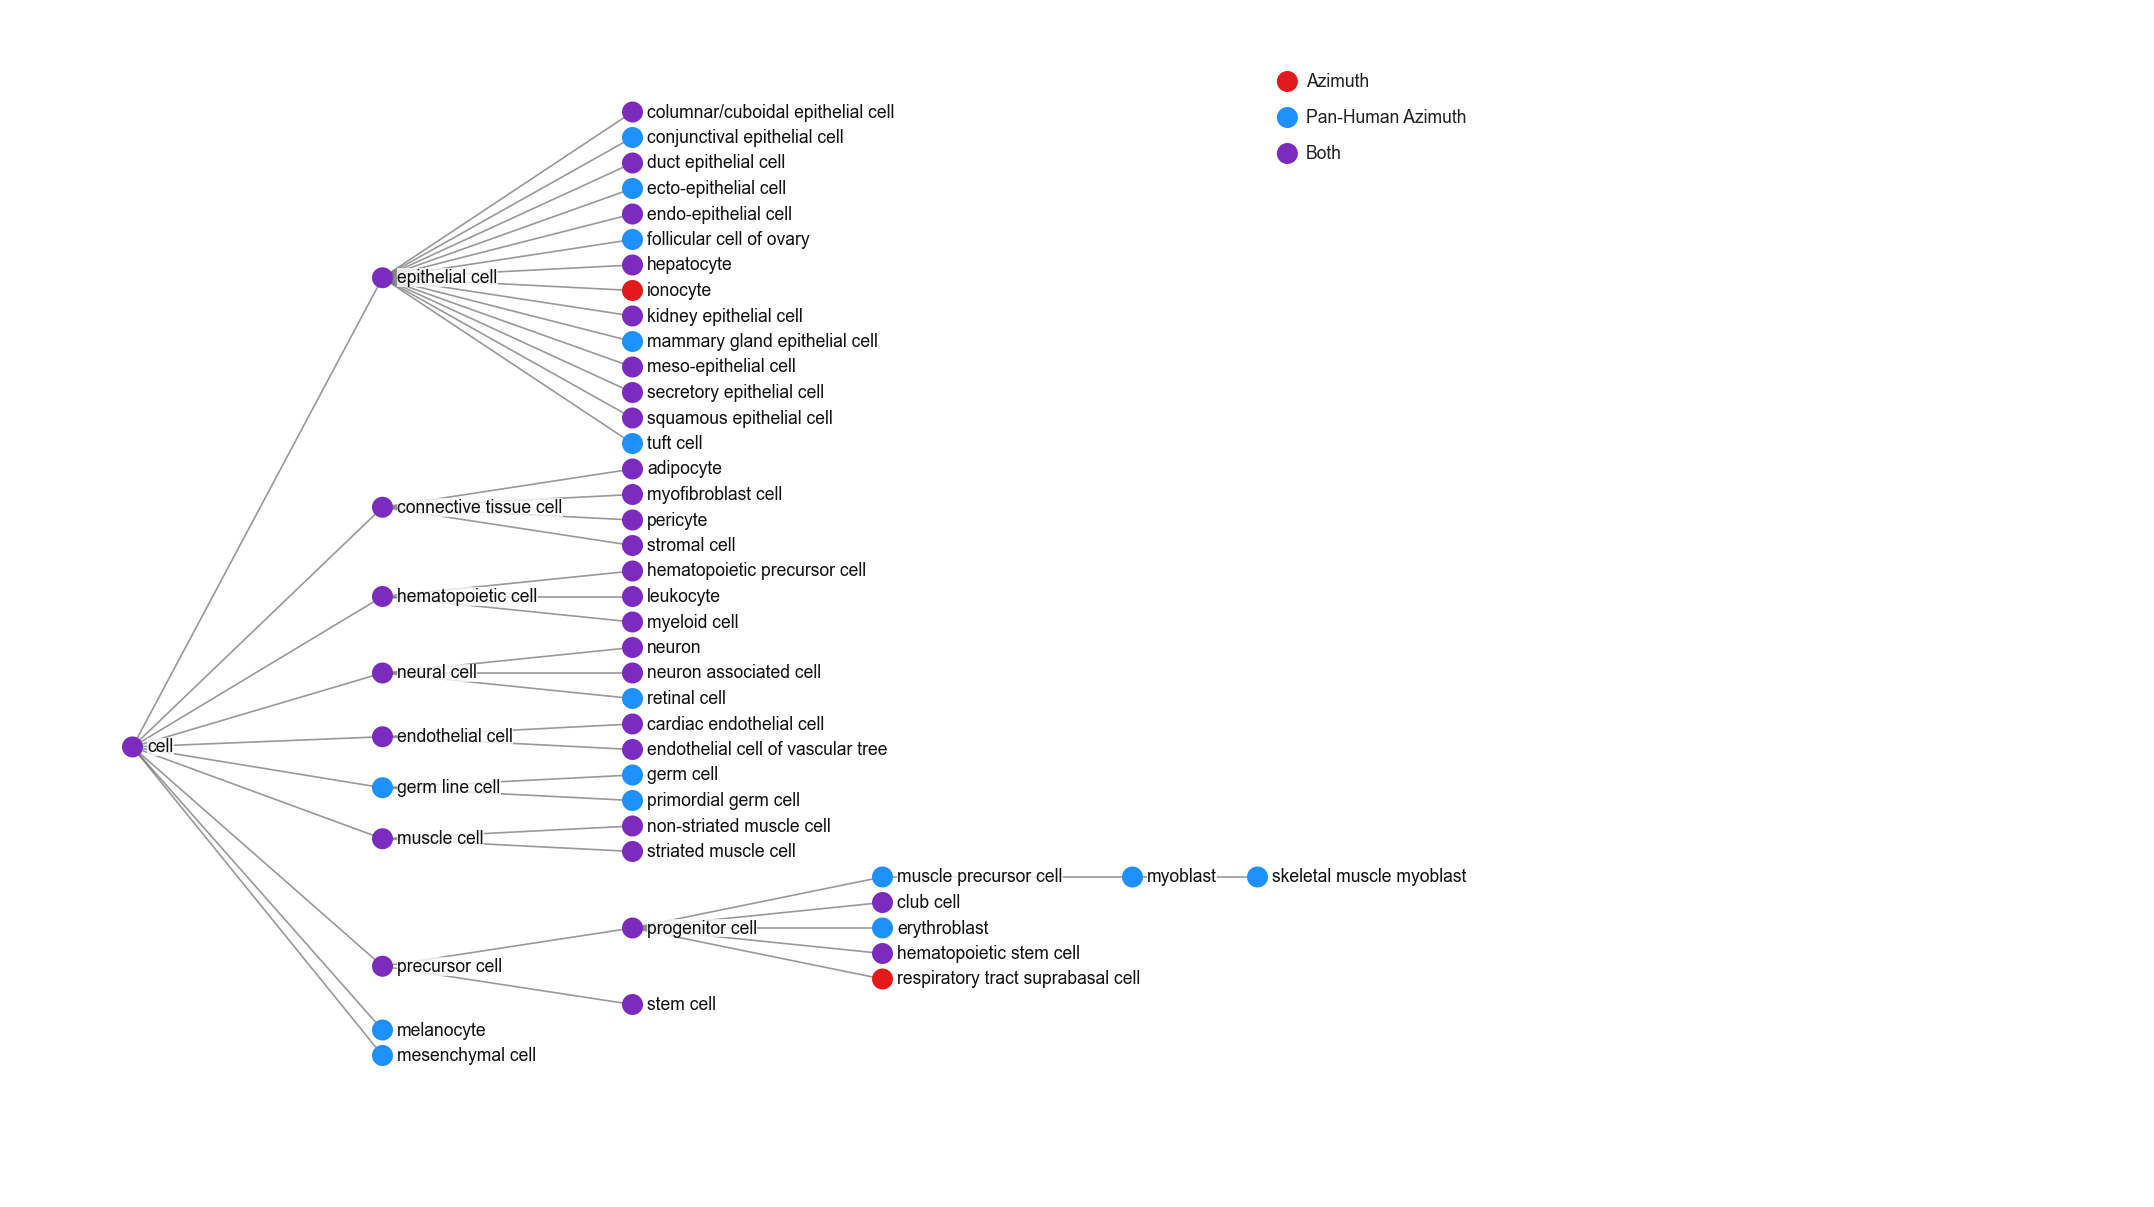

In [7]:
# Step 3: Create tree 1.
SHORTENED_MYOBLAST_CHILD_ID = "CL:0000515"
def create_tree(
    tree_rows,
    *,
    output_stem,
    label_position,
    leaf_step,
    column_dx,
    left_margin,
    label_gap,
):
    node_sources = defaultdict(set)
    node_labels = {}
    parents = defaultdict(set)
    children = defaultdict(set)
    edge_counts = Counter()

    for source_norm, path in tree_rows:
        previous_id = None
        for node_id, node_label in path:
            node_sources[node_id].add(source_norm)
            node_labels[node_id] = node_label

            if previous_id and previous_id != node_id:
                parents[node_id].add(previous_id)
                children[previous_id].add(node_id)
                edge_counts[(previous_id, node_id)] += 1
            previous_id = node_id

    if not node_sources:
        raise ValueError("No nodes were found for this tree.")

    roots = [node for node in node_sources if not parents[node]]
    if not roots:
        roots = [min(node_sources)]

    depth = {}
    queue = deque()
    for root in sorted(roots, key=lambda node: (node_labels.get(node, ""), node)):
        depth[root] = 0
        queue.append(root)

    while queue:
        node = queue.popleft()
        for child in sorted(
            children[node],
            key=lambda candidate: (
                -edge_counts[(node, candidate)],
                node_labels.get(candidate, ""),
                candidate,
            ),
        ):
            candidate_depth = depth[node] + 1
            if child not in depth or candidate_depth < depth[child]:
                depth[child] = candidate_depth
                queue.append(child)

    primary_parent = {}
    for node in node_sources:
        if parents[node]:
            primary_parent[node] = sorted(
                parents[node],
                key=lambda parent: (
                    -edge_counts[(parent, node)],
                    depth.get(parent, 999),
                    node_labels.get(parent, ""),
                    parent,
                ),
            )[0]

    primary_children = defaultdict(list)
    for child, parent in primary_parent.items():
        primary_children[parent].append(child)
    for parent in primary_children:
        primary_children[parent].sort(
            key=lambda child: (
                depth.get(child, 999),
                -len(children[child]),
                node_labels.get(child, ""),
                child,
            )
        )

    y_positions = {}
    cursor = 0.0

    def assign_y(node):
        nonlocal cursor
        node_children = primary_children.get(node, [])
        if not node_children:
            y_positions[node] = cursor
            cursor += leaf_step
            return
        for child in node_children:
            assign_y(child)
        y_positions[node] = sum(y_positions[child] for child in node_children) / len(node_children)

    ordered_roots = sorted(roots, key=lambda node: (node_labels.get(node, ""), node))
    for root in ordered_roots:
        assign_y(root)

    for node in sorted(node_sources, key=lambda node: (depth.get(node, 999), node_labels.get(node, ""), node)):
        if node not in y_positions:
            y_positions[node] = cursor
            cursor += leaf_step

    max_depth = max(depth.values())
    min_y = min(y_positions.values())
    max_y = max(y_positions.values())

    top_margin = 80
    right_label_space = 310
    right_legend_space = 460
    row_dy = 8.5
    node_diameter = 21
    width = left_margin + max_depth * column_dx + right_label_space + right_legend_space
    layout_height = max(1.0, max_y - min_y) * row_dy
    height = top_margin + layout_height + 160
    vertical_offset = top_margin + max(0.0, (height - top_margin - 140 - layout_height) / 2)

    horizontal_offsets = {SHORTENED_MYOBLAST_CHILD_ID: -column_dx / 2}
    positions = {
        node: (
            left_margin + depth.get(node, 0) * column_dx + horizontal_offsets.get(node, 0),
            vertical_offset + (y_positions[node] - min_y) * row_dy,
        )
        for node in node_sources
    }

    fig = plt.figure(figsize=(width / 120, height / 120), dpi=120)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.axis("off")

    for parent, child in edge_counts:
        parent_x, parent_y = positions[parent]
        child_x, child_y = positions[child]
        is_primary = primary_parent.get(child) == parent
        ax.plot(
            [parent_x + node_diameter / 2, child_x + node_diameter / 2],
            [parent_y + node_diameter / 2, child_y + node_diameter / 2],
            color="#4A4A4A",
            linewidth=1.0 if is_primary else 0.8,
            alpha=0.56 if is_primary else 0.22,
            zorder=1,
        )

    node_texts = {}
    for node, (x, y) in positions.items():
        sources = node_sources[node]
        if sources == INCLUDED_SOURCES:
            fill_color = OVERLAP_NODE_FILL_COLOR
        elif "azimuth" in sources:
            fill_color = AZIMUTH_NODE_FILL_COLOR
        else:
            fill_color = PAN_HUMAN_AZIMUTH_NODE_FILL_COLOR

        ax.add_patch(
            Circle(
                (x + node_diameter / 2, y + node_diameter / 2),
                radius=node_diameter / 2,
                linewidth=0,
                edgecolor="none",
                facecolor=fill_color,
                zorder=2,
            )
        )

        if label_position == "right":
            text_x, text_y, horizontal, vertical = x + node_diameter + label_gap, y + node_diameter / 2, "left", "center"
        else:
            text_x, text_y, horizontal, vertical = x + node_diameter / 2, y + node_diameter + label_gap, "center", "top"

        node_texts[node] = ax.text(
            text_x,
            text_y,
            node_labels.get(node, node),
            fontsize=LABEL_FONT_SIZE,
            color="#111111",
            ha=horizontal,
            va=vertical,
            clip_on=False,
            zorder=3,
            bbox={"facecolor": "#FFFFFF", "edgecolor": "none", "alpha": 0.78, "pad": 0.18},
        )

    # Align all legend nodes in one left column while preserving the requested right edge.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    alignment_text = node_texts.get(SHORTENED_MYOBLAST_CHILD_ID)
    if alignment_text:
        alignment_bbox = alignment_text.get_window_extent(renderer=renderer)
        legend_right_x = ax.transData.inverted().transform((alignment_bbox.x1, alignment_bbox.y1))[0]
    else:
        legend_right_x = left_margin + max_depth * column_dx + right_label_space + 220

    legend_items = [
        (AZIMUTH_NODE_FILL_COLOR, "Azimuth"),
        (PAN_HUMAN_AZIMUTH_NODE_FILL_COLOR, "Pan-Human Azimuth"),
        (OVERLAP_NODE_FILL_COLOR, "Both"),
    ]
    measure_text = ax.text(0, 0, max((label for _, label in legend_items), key=len), fontsize=LABEL_FONT_SIZE)
    fig.canvas.draw()
    measure_bbox = measure_text.get_window_extent(renderer=fig.canvas.get_renderer())
    measure_text.remove()
    max_label_width = ax.transData.inverted().transform((measure_bbox.x1, measure_bbox.y1))[0] - ax.transData.inverted().transform((measure_bbox.x0, measure_bbox.y0))[0]
    legend_text_left_x = legend_right_x - max_label_width
    legend_circle_x = legend_text_left_x - 8 - node_diameter / 2

    legend_y = 70
    for color, label in legend_items:
        ax.add_patch(
            Circle(
                (legend_circle_x, legend_y),
                radius=node_diameter / 2,
                linewidth=0,
                edgecolor="none",
                facecolor=color,
                zorder=2,
            )
        )
        ax.text(
            legend_text_left_x,
            legend_y,
            label,
            fontsize=LABEL_FONT_SIZE,
            ha="left",
            va="center",
            color="#222222",
            zorder=3,
        )
        legend_y += 36


create_tree(
    tree1_rows,
    output_stem="ctann-v9-top3-azimuth-pan-human-five-step-notebook-progenitor-expanded-compact-myoblast-legend-nodes-left-align",
    label_position="right",
    leaf_step=3.0,
    column_dx=250,
    left_margin=110,
    label_gap=4,
)
